<a href="https://colab.research.google.com/github/Huii0529/Data-Science-Project/blob/main/STQD6014_PROJECT2_P167347.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.0 INTRODUCTION**

### **Uneven Growth: Analyzing Population Concentration and Regional Disparities in Malaysia**

Population concentration affects economic output, infrastructure planning,
and regional development. In Malaysia, some states attract more people
and economic activities than others, leading to uneven growth.

This study analyzes population distribution across Malaysian states from 2015–2023
and explores the relationship between population size and state-level GDP.


Datasets:
1. https://data.gov.my/data-catalogue/population_malaysia
2. https://data.gov.my/data-catalogue/population_state
3. https://data.gov.my/data-catalogue/gdp_state_real_supply

## **1.1 PROBLEM STATEMENT**

- Are populations evenly distributed across Malaysian states?
- Is population size correlated with state GDP?

## **1.2 HYPOTHESIS TESTING**

- H₀: Population size is not related to GDP.
- H₁: States with larger populations have higher GDP.

# **2.0 DATA COLLECTION**

Three datasets were retrieved from the Department of Statistics Malaysia (DOSM)
Open Data portal (OpenDOSM). These datasets provide authoritative demographic
and economic statistics at both national and state levels. The datasets were
combined to support an integrated analysis of population distribution and
regional economic disparities.

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read CSV data by using URL
urls = {
    "population_malaysia": "https://storage.dosm.gov.my/population/population_malaysia.csv",
    "population_state": "https://storage.dosm.gov.my/population/population_state.csv",
    "gdp": "https://storage.dosm.gov.my/gdp/gdp_state_real_supply.csv"
}

# Load datasets into dictionary
dataframes = {name: pd.read_csv(url) for name, url in urls.items()}

# Convert date column to datetime
for name, df in dataframes.items():
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')

## **2.1 Data Cleaning and Preparation**

In [3]:
# Check Data Structure

def check_structure(df, name):
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print("\nColumns and Data Types:")
    print(df.dtypes)
    print("\nFirst 5 Rows:")
    print(df.head())
    print("\nMissing Values:")
    print(df.isna().sum())
    print("\nUnique values per column:")
    for col in df.columns:
        print(f"{col}: {df[col].nunique()}")
    print("\n" + "="*50 + "\n")

# Apply to all datasets
for name, df in dataframes.items():
    check_structure(df, name)

--- population_malaysia ---
Shape: (17415, 5)

Columns and Data Types:
date          datetime64[ns]
sex                   object
age                   object
ethnicity             object
population           float64
dtype: object

First 5 Rows:
        date   sex      age ethnicity  population
0 1970-01-01  both  overall   overall     10881.8
1 1970-01-01  both      0-4   overall      1702.4
2 1970-01-01  both      5-9   overall      1690.3
3 1970-01-01  both    10-14   overall      1454.7
4 1970-01-01  both    15-19   overall      1197.6

Missing Values:
date          0
sex           0
age           0
ethnicity     0
population    0
dtype: int64

Unique values per column:
date: 56
sex: 3
age: 21
ethnicity: 9
population: 6955


--- population_state ---
Shape: (263679, 6)

Columns and Data Types:
state                 object
date          datetime64[ns]
sex                   object
age                   object
ethnicity             object
population           float64
dtype: object

Firs

In [4]:
# Drop rows where 'state' is 'supra' from the GDP DataFrame
dataframes['gdp'] = dataframes['gdp'][dataframes['gdp']['state'] != 'supra']

Dropping 'Supra' values will not impact the overall results, as this entry does not represent a specific Malaysian state, and all other states have complete GDP data.

In [5]:
# Fill categorical missing values
for col in ['state','sex','age','ethnicity','series','sector']:
    for df in dataframes.values():
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

# Fill numeric missing values using interpolation or median
dataframes['population_state']['population'] = dataframes['population_state'].groupby(['state','age'])['population'].transform(lambda x: x.interpolate())
dataframes['population_malaysia']['population'] = dataframes['population_malaysia'].groupby(['age'])['population'].transform(lambda x: x.interpolate())
gdp_abs = dataframes['gdp'][dataframes['gdp']['series']=='abs'].copy()
gdp_abs['value'] = gdp_abs.groupby(['state','sector'])['value'].transform(lambda x: x.interpolate())

In [6]:
#Filter by year
START_YEAR = 2015
END_YEAR = 2023

# Filter population and GDP (gdp_abs is already filtered for 'abs' series from previous steps)
pop_state_filtered = dataframes['population_state'][(dataframes['population_state']['date'].dt.year >= START_YEAR) & (dataframes['population_state']['date'].dt.year <= END_YEAR)]
pop_malaysia_filtered = dataframes['population_malaysia'][(dataframes['population_malaysia']['date'].dt.year >= START_YEAR) & (dataframes['population_malaysia']['date'].dt.year <= END_YEAR)]
gdp_filtered = gdp_abs[(gdp_abs['date'].dt.year >= START_YEAR) & (gdp_abs['date'].dt.year <= END_YEAR)]

# Aggregate population by state-year (overall age)
pop_state_agg = pop_state_filtered[pop_state_filtered['age']=='overall'].groupby(['state','date']).agg({'population':'sum'}).reset_index()

# Aggregate GDP by state-year (sum across all sectors to get total GDP per state/date)
gdp_total = gdp_filtered.groupby(['state','date']).agg({'value':'sum'}).reset_index()

# Merge datasets
merged_df = pd.merge(pop_state_agg, gdp_total, on=['state','date'], how='left')
merged_df['year'] = merged_df['date'].dt.year

# Fill remaining missing numeric values with median
merged_df['population'] = merged_df['population'].fillna(merged_df['population'].median())
merged_df['value'] = merged_df['value'].fillna(merged_df['value'].median())

merged_df.head()

,state,date,population,value,year
0,Johor,2015-01-01,14441.1,220004.442,2015
1,Johor,2016-01-01,14606.5,233364.454,2016
2,Johor,2017-01-01,14789.0,247122.653,2017
3,Johor,2018-01-01,14997.3,261171.889,2018
4,Johor,2019-01-01,15045.4,268451.875,2019


In [7]:
display(merged_df)

,state,date,population,value,year
0,Johor,2015-01-01,14441.1,220004.442,2015
1,Johor,2016-01-01,14606.5,233364.454,2016
2,Johor,2017-01-01,14789.0,247122.653,2017
3,Johor,2018-01-01,14997.3,261171.889,2018
4,Johor,2019-01-01,15045.4,268451.875,2019
...,...,...,...,...,...
139,W.P. Putrajaya,2019-01-01,414.8,110880.207,2019
140,W.P. Putrajaya,2020-01-01,436.7,110880.207,2020
141,W.P. Putrajaya,2021-01-01,460.7,110880.207,2021
142,W.P. Putrajaya,2022-01-01,467.9,110880.207,2022


# **3.0 RESULTS AND DISCUSSIONS**


## **3.1 Correlation between population and GDP**

In [23]:
# Correlation between population and GDP
corr_matrix = merged_df[['population','value']].corr()
print("Correlation matrix:\n", corr_matrix)

Correlation matrix:
             population     value
population    1.000000  0.800987
value         0.800987  1.000000


The analysis indicates a positive relationship between population size and state GDP in Malaysia, supporting the alternative hypothesis (H₁) and rejecting the null hypothesis (H₀).

## **3.2 Data Visualization and Data Analysis**

**Plot 1: Population by State (2015 - 2023)**

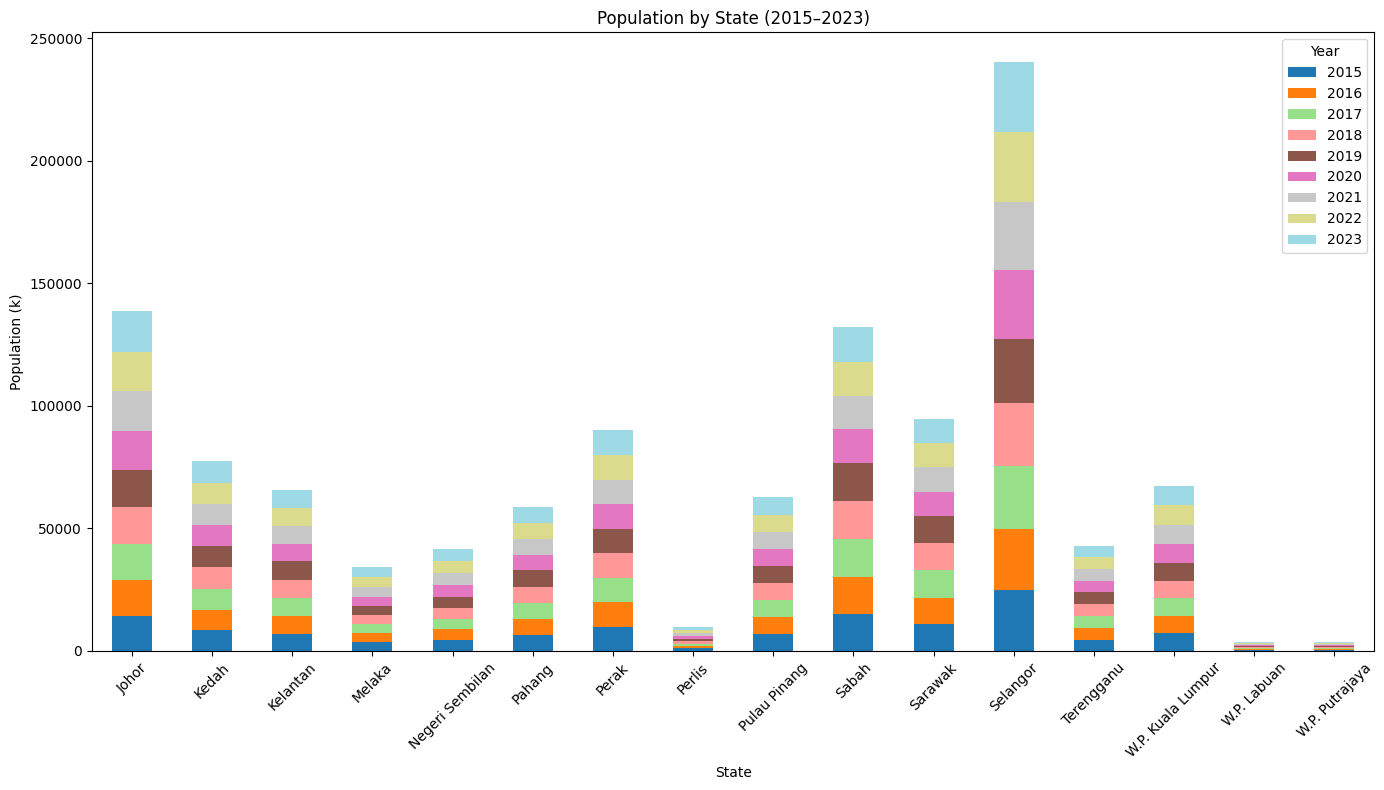

In [38]:
stack_df = merged_df.pivot_table(
    index='state',
    columns='year',
    values='population',
    aggfunc='sum'
).fillna(0)

# Arrange states alphabetically
stack_df = stack_df.sort_index()

# Vertical stacked bar chart
stack_df.plot(
    kind='bar',
    stacked=True,
    colormap='tab20',
    figsize=(14,8)
)
plt.ylabel("Population (k)")
plt.xlabel("State")
plt.title("Population by State (2015–2023)")
plt.legend(title="Year", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Plot 1 shows that population distribution across Malaysian states between 2015 and 2023 is uneven. Selangor consistently has the largest population and shows steady growth throughout the period, followed by Johor and the Federal Territory of Kuala Lumpur. Kedah and Kelantan also record relatively high population levels compared to other states, although their growth patterns are more moderate.

States such as Perlis, W.P Putrajaya and W.P. Labuan remain at the lower end of the population scale, with minimal changes over time. This contrast indicates that population growth is concentrated in a limited number of states rather than being evenly distributed nationwide.

The distribution pattern suggests that population concentration is closely associated with urbanisation and economic activity. While highly urbanised states combine large populations with strong economic performance, states such as Kedah and Kelantan demonstrate that higher population size alone does not necessarily correspond to higher economic output. This population imbalance provides important context for analysing regional economic disparities in Malaysia.

**Plot 2: Population Share by State (2023)**

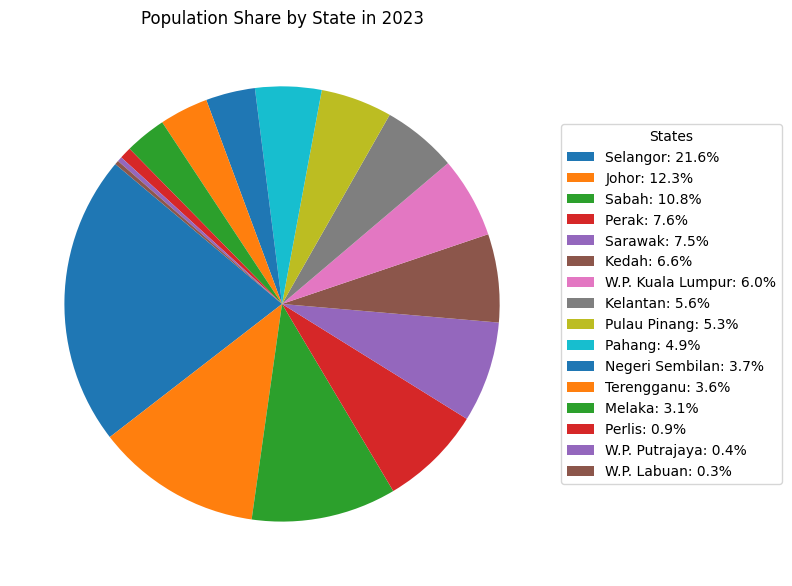

In [37]:
latest_year = merged_df['year'].max()

pop_latest = (
    merged_df[merged_df['year'] == latest_year]
    .groupby('state', as_index=False)['population']
    .sum()
)

# Calculate percentage
pop_latest['percentage'] = (
    pop_latest['population'] / pop_latest['population'].sum()
) * 100

# Sort descending for better visualization
pop_latest = pop_latest.sort_values('percentage', ascending=False)

plt.figure(figsize=(8,8))
wedges, texts = plt.pie(
    pop_latest['percentage'],
    startangle=140
)

legend_labels = [f'{s}: {p:.1f}%' for s, p in zip(pop_latest['state'], pop_latest['percentage'])]

plt.title(f"Population Share by State in {latest_year}")
plt.legend(wedges, legend_labels, title="States", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

The pie chart illustrates the percentage distribution of Malaysia’s population by state in the latest available year. Selangor accounts for the largest share of the national population, followed by Johor, Kedah, Kelantan, and the Federal Territory of Kuala Lumpur. Together, these states represent a substantial proportion of Malaysia’s total population, indicating strong demographic concentration.

In contrast, smaller states such as Perlis and Labuan contribute only a small percentage to the overall population. The visual emphasises that population distribution across states is uneven, with a limited number of states accounting for a large share of residents. This concentration provides important context for understanding regional economic disparities and supports further analysis of the relationship between population size and GDP.

**Plot 3: Overall GDP by State (2023)**

/tmp/ipython-input-4146146579.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


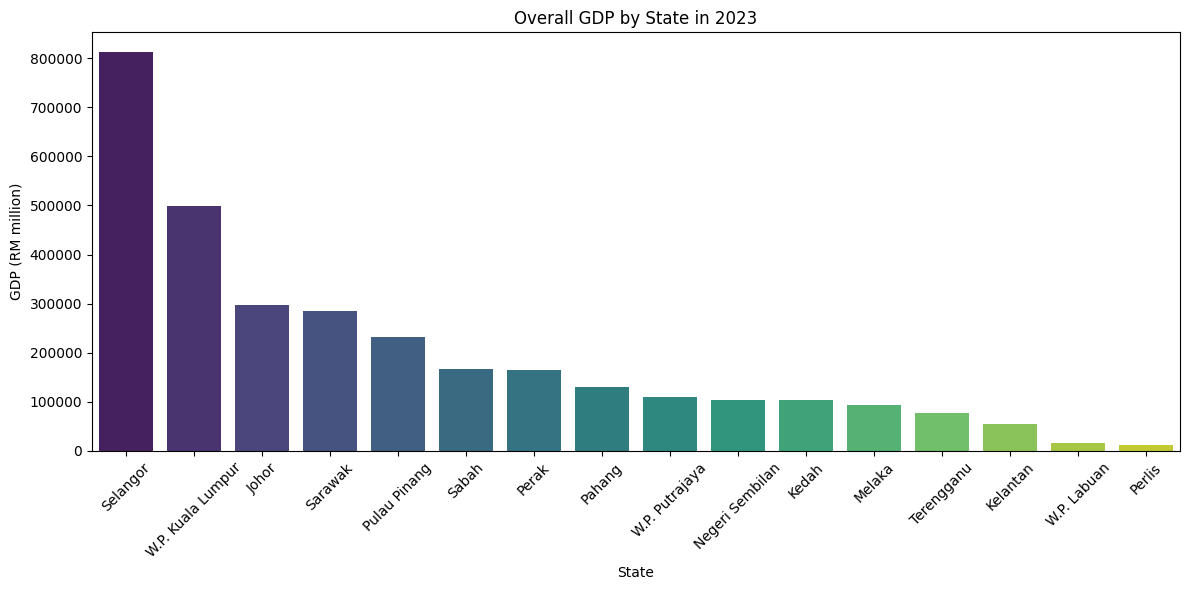

In [35]:
latest_year = merged_df['year'].max()

gdp_latest = (
    merged_df[merged_df['year'] == latest_year]
    .groupby('state', as_index=False)['value']
    .sum()
)

# Sort by GDP descending
gdp_latest = gdp_latest.sort_values('value', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    data=gdp_latest,
    x='state',
    y='value',
    palette='viridis'
)

plt.title(f"Overall GDP by State in {latest_year}")
plt.xlabel("State")
plt.ylabel("GDP (RM million)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


This bar chart presents the overall GDP by state for the latest year (2023). Selangor records the highest GDP among all states, showing a substantial gap compared to others. The Federal Territory of Kuala Lumpur and Johor follow as the second and third largest contributors, respectively. Several states, including Kedah and Kelantan, exhibit moderate GDP levels despite having relatively large populations, while smaller states such as Perlis and Labuan contribute minimally.

The distribution highlights strong economic concentration in a small number of states, particularly those with higher levels of urbanisation and industrial activity. This pattern supports the study’s hypothesis that population size is positively related to economic output, while also indicating that economic structure and sectoral composition play an important role in determining state-level GDP (Department of Statistics Malaysia, 2024).

**Plot 4: Population vs GDP (2023)**



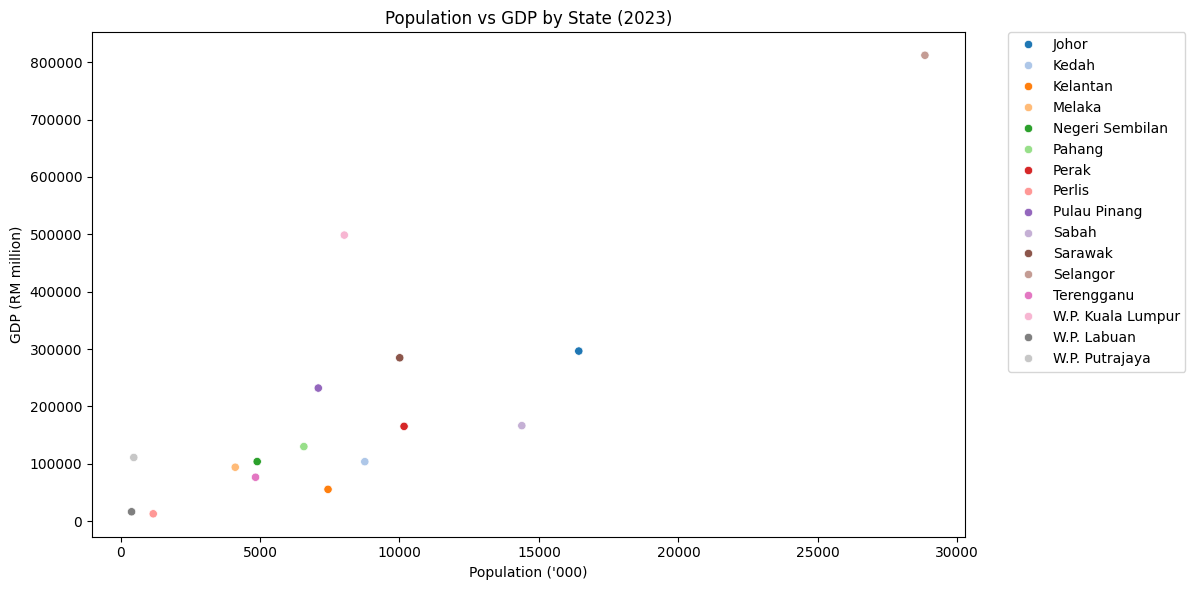

In [22]:
latest_year = merged_df['year'].max()
latest_data = merged_df[merged_df['year'] == latest_year].copy()

plt.figure(figsize=(10,6))
sns.scatterplot(data=latest_data, x='population', y='value', hue='state', palette='tab20', legend='full')
plt.title(f"Population vs GDP by State ({latest_year})")
plt.xlabel("Population ('000)")
plt.ylabel("GDP (RM million)")
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

Selangor stands out as the most populous state and consistently records the highest GDP contribution, demonstrating a significant gap compared to other states. In 2023, Selangor contributed 25.9% of Malaysia’s GDP, followed by Kuala Lumpur, Johor, Sarawak, Penang, and Sabah. Together, these six states accounted for approximately 73% of the national economy, highlighting strong economic concentration.

**Plot 5: Population by Age Group in Selangor (2023)**

In [49]:
latest_year = merged_df['year'].max()

selangor_pop_data = dataframes['population_state'][
    (dataframes['population_state']['state'] == 'Selangor') &
    (dataframes['population_state']['date'].dt.year == latest_year)
].copy()

# Only keep both sexes
selangor_age_df = selangor_pop_data[selangor_pop_data['sex'] == 'both']

# Exclude 'overall' age group
selangor_age_df = selangor_age_df[selangor_age_df['age'] != 'overall']

# Aggregate population by age group
selangor_age_df = selangor_age_df.groupby('age', as_index=False)['population'].sum()

# Sort age groups properly
age_order = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
             '40-44','45-49','50-54','55-59','60-64','65-69','70-74',
             '75-79','80-84','85+']

selangor_age_df['age'] = pd.Categorical(selangor_age_df['age'], categories=age_order, ordered=True)
selangor_age_df = selangor_age_df.sort_values('age')

print(selangor_age_df.head())

     age  population
0    0-4      1008.2
9    5-9      1072.8
1  10-14       983.4
2  15-19      1006.9
3  20-24      1186.5


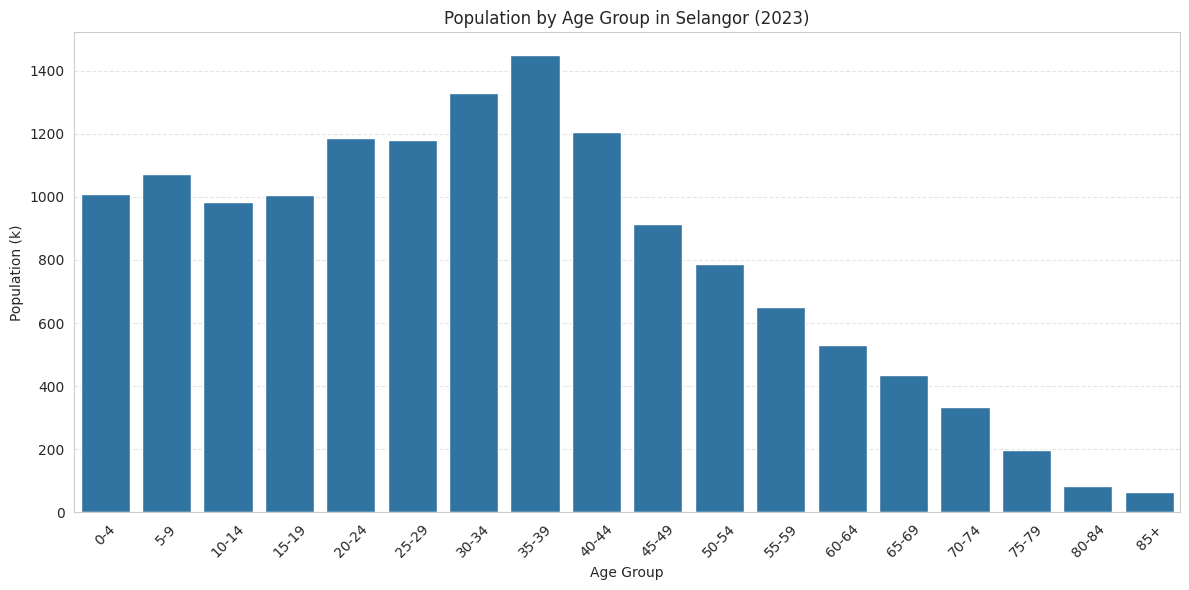

In [54]:
plt.figure(figsize=(12,6))
sns.barplot(x='age', y='population', data=selangor_age_df)
plt.xticks(rotation=45)
plt.title(f"Population by Age Group in Selangor ({latest_year})")
plt.xlabel("Age Group")
plt.ylabel("Population (k)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The bar chart illustrates the population distribution across different age groups in Selangor for the year 2023. The working-age population, defined as individuals aged 15–64, clearly dominates the demographic profile, indicating a strong labor force available to support the state’s economic activities. Younger age groups (0–14 years) and older age groups (65 years and above) constitute a smaller proportion of the total population, suggesting a relatively moderate dependency ratio. This demographic composition highlights why Selangor consistently demonstrates robust economic performance, as a higher proportion of working-age individuals tends to correlate with increased productivity and higher GDP output. Understanding the age structure provides key insights into workforce potential and planning for social services, economic policies, and future population growth trends.

# **4.0 Suggestion and Next Steps**

The analysis reveals that population and economic activity are concentrated in a few states (Selangor, Kuala Lumpur, and Johor), leaving smaller states (Perlis, Labuan, Melaka) with slower growth. To address this imbalance, policymakers should implement targeted regional development strategies, including investment in infrastructure, social services, and economic opportunities in less-populated states. Enhancing these areas could help retain population, reduce migration to urban centers, and stimulate local economic activity.

Future research should incorporate additional datasets, such as internal migration, urbanization patterns, employment, and education, to better understand the factors driving population concentration and economic disparities. State-level population and GDP forecasting would also support long-term planning for housing, healthcare, and economic development. Evaluating GDP per capita alongside total GDP can provide insight into economic efficiency and living standards, guiding policies that encourage sustainable growth and equitable resource allocation across all Malaysian states.

# **5.0 Conclusion**

This study aimed to examine whether populations are evenly distributed across Malaysian states and whether population size is related to state GDP. The analysis indicates that population growth and economic activity are highly concentrated in a few states, particularly Selangor, Johor, and W.P. Kuala Lumpur, while smaller states experience slower growth. This supports rejecting the null hypothesis (H₀), confirming that states with larger populations tend to have higher GDP (H₁). From a data science perspective, these findings suggest that population concentration drives economic output, highlighting the need for policymakers to implement strategies that encourage balanced regional development, equitable resource allocation, and opportunities for less-populated states to grow sustainably.


# **References**

1. Mail, M. (2024, July 2). DOSM: Selangor top contributor to Malaysia’s 2023 GDP. Malay Mail. https://www.malaymail.com/news/malaysia/2024/07/02/dosm-selangor-top-contributor-to-malaysias-2023-gdp/142535#:~:text=DoSM:%20Selangor%20top%20contributor%20to%20Malaysia's%202023%20GDP%20%7C%20Malay%20Mail

2.